# Compare `expand_conv_core` (original) vs `expand_conv_core_edt` (EDT) on Demo Radar Data

Visualize the differences between the **original sequential binary-dilation** (`expand_conv_core`)
and the **EDT Voronoi partition** (`expand_conv_core_edt`) on NEXRAD or CSAPR-2 demo data.

**Pipeline run for each file:**
1. `get_composite_reflectivity_generic` — load and preprocess 3D reflectivity
2. `mod_steiner_classification` (fft convolution, orig dilate) — get `score_dilate` (shared input to both expand methods)
3. `expand_conv_core` — original: sequential dilation per core, largest-core-wins at contested boundaries
4. `expand_conv_core_edt` — EDT: global Voronoi partition, nearest-core assignment

**Expected difference:** Only at equidistant boundary pixels between closely spaced cores.
For well-separated cores, results are identical.


In [12]:
# ── USER CONFIGURATION ──────────────────────────────────────────────────────
# Choose demo dataset: 'nexrad' or 'csapr'
# DEMO = 'nexrad'
DEMO = 'csapr'

# Top-N worst files to visualize with 3-panel plots
N_TOP_PLOTS = 10

DATA_ROOT = '/ccsopen/home/zhe1feng1/data/demo'


In [2]:
import glob
import os
import sys
import time

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams['figure.dpi'] = 200

sys.path.insert(0, '/ccsopen/home/zhe1feng1/program/PyFLEXTRKR-dev')
from pyflextrkr.idcells_reflectivity import get_composite_reflectivity_generic
from pyflextrkr.steiner_func import (
    expand_conv_core,
    expand_conv_core_edt,
    make_dilation_step_func,
    mod_steiner_classification,
)


## 1  Configuration

In [3]:
# ── Steiner / expand parameters (same for both NEXRAD and CSAPR demos) ──────
DX                = 500.0    # m
BKG_RAD           = 11000.0  # m
RADII_EXPAND      = np.array([1.0, 2.0, 3.0, 4.0, 5.0])  # km
MINZDIFF          = 10.0
ABS_CONV_THRES    = 60.0
TRUNC_ZCONV_THRES = 55.0
WEAK_ECHO_THRES   = 15.0
MIN_COREAREA      = 4.0   # km^2
TYPES_STEINER     = {'NO_SURF_ECHO': 1, 'WEAK_ECHO': 2, 'STRATIFORM': 3, 'CONVECTIVE': 4}

BKG_BIN, CONV_RAD_BIN = make_dilation_step_func(
    mindBZuse=25, dBZforMaxConvRadius=60,
    bkg_refl_increment=5, conv_rad_increment=0.5,
    conv_rad_start=1.0, maxConvRadius=5,
)

# ── Demo-specific I/O configuration ─────────────────────────────────────────
_NEXRAD_CONF = dict(
    input_dir=f'{DATA_ROOT}/cell_radar/nexrad/input',
    pattern='KHGX*.nc',
    config=dict(
        dx=500, dy=500,
        x_dimname='x', y_dimname='y', z_dimname='z',
        time_dimname='time', time_coordname='time',
        x_coordname='x', y_coordname='y', z_coordname='z',
        lon_coordname='point_longitude', lat_coordname='point_latitude',
        radar_lon_varname='origin_longitude', radar_lat_varname='origin_latitude',
        radar_alt_varname='alt',
        reflectivity_varname='reflectivity',
        radar_sensitivity=0.0,
        sfc_dz_min=1000, sfc_dz_max=3000,
        terrain_file=None, elev_varname=None,
        rangemask_varname='mask110',
        z_coord_type='height', input_format='netcdf',
    ),
)

_CSAPR_CONF = dict(
    input_dir=f'{DATA_ROOT}/cell_radar/csapr/input',
    pattern='taranis_corcsapr2*.nc',
    config=dict(
        dx=500, dy=500,
        x_dimname='x', y_dimname='y', z_dimname='z',
        time_dimname='time', time_coordname='time',
        x_coordname='x', y_coordname='y', z_coordname='z',
        lon_coordname='point_longitude', lat_coordname='point_latitude',
        radar_lon_varname='origin_longitude', radar_lat_varname='origin_latitude',
        radar_alt_varname='alt',
        reflectivity_varname='taranis_attenuation_corrected_reflectivity',
        radar_sensitivity=0.0,
        sfc_dz_min=500, sfc_dz_max=3000,
        terrain_file=None, elev_varname=None,
        rangemask_varname='mask110',
        z_coord_type='height', input_format='netcdf',
    ),
)

# Route based on DEMO choice
demo_conf = _NEXRAD_CONF if DEMO == 'nexrad' else _CSAPR_CONF
input_dir = demo_conf['input_dir']
pattern   = demo_conf['pattern']
io_config = demo_conf['config']

input_files = sorted(glob.glob(os.path.join(input_dir, pattern)))
print(f'DEMO    : {DEMO}')
print(f'Files   : {len(input_files)}')
if input_files:
    print(f'  First : {os.path.basename(input_files[0])}')
    print(f'  Last  : {os.path.basename(input_files[-1])}')


DEMO    : csapr
Files   : 29
  First : taranis_corcsapr2cfrppiqcM1.c1.20190125.164511_gridded.nc
  Last  : taranis_corcsapr2cfrppiqcM1.c1.20190125.234503_gridded.nc


## 2  Run pipeline on all files

In [4]:
results = []
lat2d = None
lon2d = None

for fi, fpath in enumerate(input_files):
    comp_dict = get_composite_reflectivity_generic(fpath, io_config)

    # Grab 2D lat/lon grid once (same for all files in the same radar dataset)
    if lat2d is None:
        lat2d = np.array(comp_dict['grid_lat']).squeeze()
        lon2d = np.array(comp_dict['grid_lon']).squeeze()

    # Parse timestamp
    tc = comp_dict['time_coords']
    ts_val = tc[0] if hasattr(tc, '__len__') else tc
    ts = pd.Timestamp(ts_val.values)

    # Step 1: Steiner classification — shared between both expand methods
    steiner_res = mod_steiner_classification(
        TYPES_STEINER, comp_dict['refl'], comp_dict['mask_goodvalues'],
        DX, DX,
        bkg_rad=BKG_RAD,
        minZdiff=MINZDIFF,
        absConvThres=ABS_CONV_THRES,
        truncZconvThres=TRUNC_ZCONV_THRES,
        weakEchoThres=WEAK_ECHO_THRES,
        bkg_bin=BKG_BIN,
        conv_rad_bin=CONV_RAD_BIN,
        min_corearea=MIN_COREAREA,
        min_cellarea=0.0,
        remove_smallcores=True,
        remove_smallcells=False,
        return_diag=False,
        convolve_method='fft',
    )
    core_dilate = steiner_res['score_dilate']

    # Step 2: Original expand
    t0 = time.time()
    exp_orig, _ = expand_conv_core(core_dilate, RADII_EXPAND, DX, DX, min_corenpix=0)
    t_orig = time.time() - t0

    # Step 3: EDT expand
    t0 = time.time()
    exp_edt, _ = expand_conv_core_edt(core_dilate, RADII_EXPAND, DX, DX, min_corenpix=0)
    t_edt = time.time() - t0

    # ── Diff statistics ──────────────────────────────────────────────────────
    cov_orig = exp_orig > 0
    cov_edt  = exp_edt  > 0

    # Binary coverage diff (orig-only / EDT-only pixels)
    diff_bin    = cov_edt.astype(np.int8) - cov_orig.astype(np.int8)  # {-1, 0, +1}
    n_edt_only  = int(np.sum(diff_bin ==  1))
    n_orig_only = int(np.sum(diff_bin == -1))
    n_agree_on  = int(np.sum(cov_orig & cov_edt))
    n_cov_diff  = n_edt_only + n_orig_only
    n_union     = int(np.sum(cov_orig | cov_edt))

    # 4-category label-diff map:
    #   -1 = orig-only       (orig covered, EDT not)
    #    0 = agree            (same label, or both background)
    #    1 = EDT-only         (EDT covered, orig not)
    #    2 = label mismatch   (both covered, but different cell IDs)
    label_diff_map = np.zeros(exp_orig.shape, dtype=np.int8)
    label_diff_map[cov_orig & ~cov_edt]                          = -1
    label_diff_map[~cov_orig & cov_edt]                          =  1
    label_diff_map[cov_orig & cov_edt & (exp_orig != exp_edt)]  =  2

    n_label_mismatch = int(np.sum(label_diff_map == 2))
    n_label_diff     = n_orig_only + n_edt_only + n_label_mismatch

    results.append(dict(
        fi=fi,
        fname=os.path.basename(fpath),
        timestamp=ts,
        exp_orig=exp_orig,
        exp_edt=exp_edt,
        diff_bin=diff_bin,
        label_diff_map=label_diff_map,
        n_edt_only=n_edt_only,
        n_orig_only=n_orig_only,
        n_agree_on=n_agree_on,
        n_cov_diff=n_cov_diff,
        n_label_mismatch=n_label_mismatch,
        n_label_diff=n_label_diff,
        n_union=n_union,
        t_orig=t_orig,
        t_edt=t_edt,
    ))

    speedup = t_orig / max(t_edt, 1e-9)
    print(f'[{DEMO} file={fi:2d}]  {ts.strftime("%Y-%m-%d %H:%M")}  '
        f'cov_diff={n_cov_diff:4d}  label_mismatch={n_label_mismatch:4d}  label_diff={n_label_diff:4d}  '
        f'orig={t_orig:.3f}s  edt={t_edt:.4f}s  speedup={speedup:.1f}x')


sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)
sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)


[csapr file= 0]  2019-01-25 16:45  cov_diff=   0  label_mismatch=   0  label_diff=   0  orig=0.112s  edt=0.0059s  speedup=19.2x


sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)


[csapr file= 1]  2019-01-25 17:00  cov_diff=   0  label_mismatch=   0  label_diff=   0  orig=0.214s  edt=0.0062s  speedup=34.3x


sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)


...

[csapr file=25]  2019-01-25 23:00  cov_diff=   0  label_mismatch=  38  label_diff=  38  orig=0.932s  edt=0.0080s  speedup=116.9x


sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)


[csapr file=26]  2019-01-25 23:15  cov_diff=   0  label_mismatch=  37  label_diff=  37  orig=0.523s  edt=0.0066s  speedup=79.1x


sfc_elev has no 'units' attribute and no override provided
Assuming sfc_elev is already in standard units (m)


[csapr file=27]  2019-01-25 23:30  cov_diff=   0  label_mismatch=  22  label_diff=  22  orig=0.417s  edt=0.0060s  speedup=69.8x
[csapr file=28]  2019-01-25 23:45  cov_diff=   0  label_mismatch=   0  label_diff=   0  orig=0.517s  edt=0.0067s  speedup=76.8x


## 3  Summary statistics

In [5]:
rows = []
for r in results:
    n_u     = r['n_union']
    speedup = r['t_orig'] / max(r['t_edt'], 1e-9)
    rows.append(dict(
        fi=r['fi'],
        timestamp=r['timestamp'].strftime('%Y-%m-%d %H:%M'),
        n_cov_diff=r['n_cov_diff'],
        pct_cov_diff=100.0 * r['n_cov_diff'] / max(n_u, 1),
        n_label_diff=r['n_label_diff'],
        pct_label_diff=100.0 * r['n_label_diff'] / max(n_u, 1),
        n_edt_only=r['n_edt_only'],
        n_orig_only=r['n_orig_only'],
        t_orig=r['t_orig'],
        t_edt=r['t_edt'],
        speedup=speedup,
    ))

df = pd.DataFrame(rows).set_index('fi')
pd.set_option('display.float_format', '{:.4f}'.format)

n_union_total      = sum(r['n_union'] for r in results)
n_cov_diff_total   = df['n_cov_diff'].sum()
n_label_diff_total = df['n_label_diff'].sum()

print(f'=== {DEMO.upper()}: expand_conv_core vs expand_conv_core_edt ({len(results)} files) ===')
print(f'Total coverage-diff pixels : {n_cov_diff_total}')
print(f'Total label-diff pixels    : {n_label_diff_total}')
print(f'Aggregate pct cov diff     : {100.0 * n_cov_diff_total / max(n_union_total, 1):.4f}%')
print(f'Aggregate pct label diff   : {100.0 * n_label_diff_total / max(n_union_total, 1):.4f}%')
print(f'Mean speedup (orig/edt)    : {df["speedup"].mean():.1f}x')
print()
display(df[['timestamp', 'n_cov_diff', 'pct_cov_diff', 'n_label_diff',
            'pct_label_diff', 'n_edt_only', 'n_orig_only', 'speedup']])


=== CSAPR: expand_conv_core vs expand_conv_core_edt (29 files) ===
Total coverage-diff pixels : 0
Total label-diff pixels    : 2118
Aggregate pct cov diff     : 0.0000%
Aggregate pct label diff   : 0.4431%
Mean speedup (orig/edt)    : 97.6x



,timestamp,n_cov_diff,pct_cov_diff,n_label_diff,pct_label_diff,n_edt_only,n_orig_only,speedup
fi,,,,,,,,
0,2019-01-25 16:45,0,0.0000,0,0.0000,0,0,19.1991
1,2019-01-25 17:00,0,0.0000,0,0.0000,0,0,34.3152
2,2019-01-25 17:15,0,0.0000,10,0.1945,0,0,86.5060
3,2019-01-25 17:30,0,0.0000,0,0.0000,0,0,69.9395
4,2019-01-25 17:45,0,0.0000,33,0.3111,0,0,97.4136
5,2019-01-25 18:00,0,0.0000,31,0.2448,0,0,111.9864
6,2019-01-25 18:15,0,0.0000,10,0.0758,0,0,92.5853
7,2019-01-25 18:30,0,0.0000,71,0.3792,0,0,104.9791
8,2019-01-25 18:45,0,0.0000,136,0.5700,0,0,166.8582


## 4  Time series: coverage diff and speedup per file

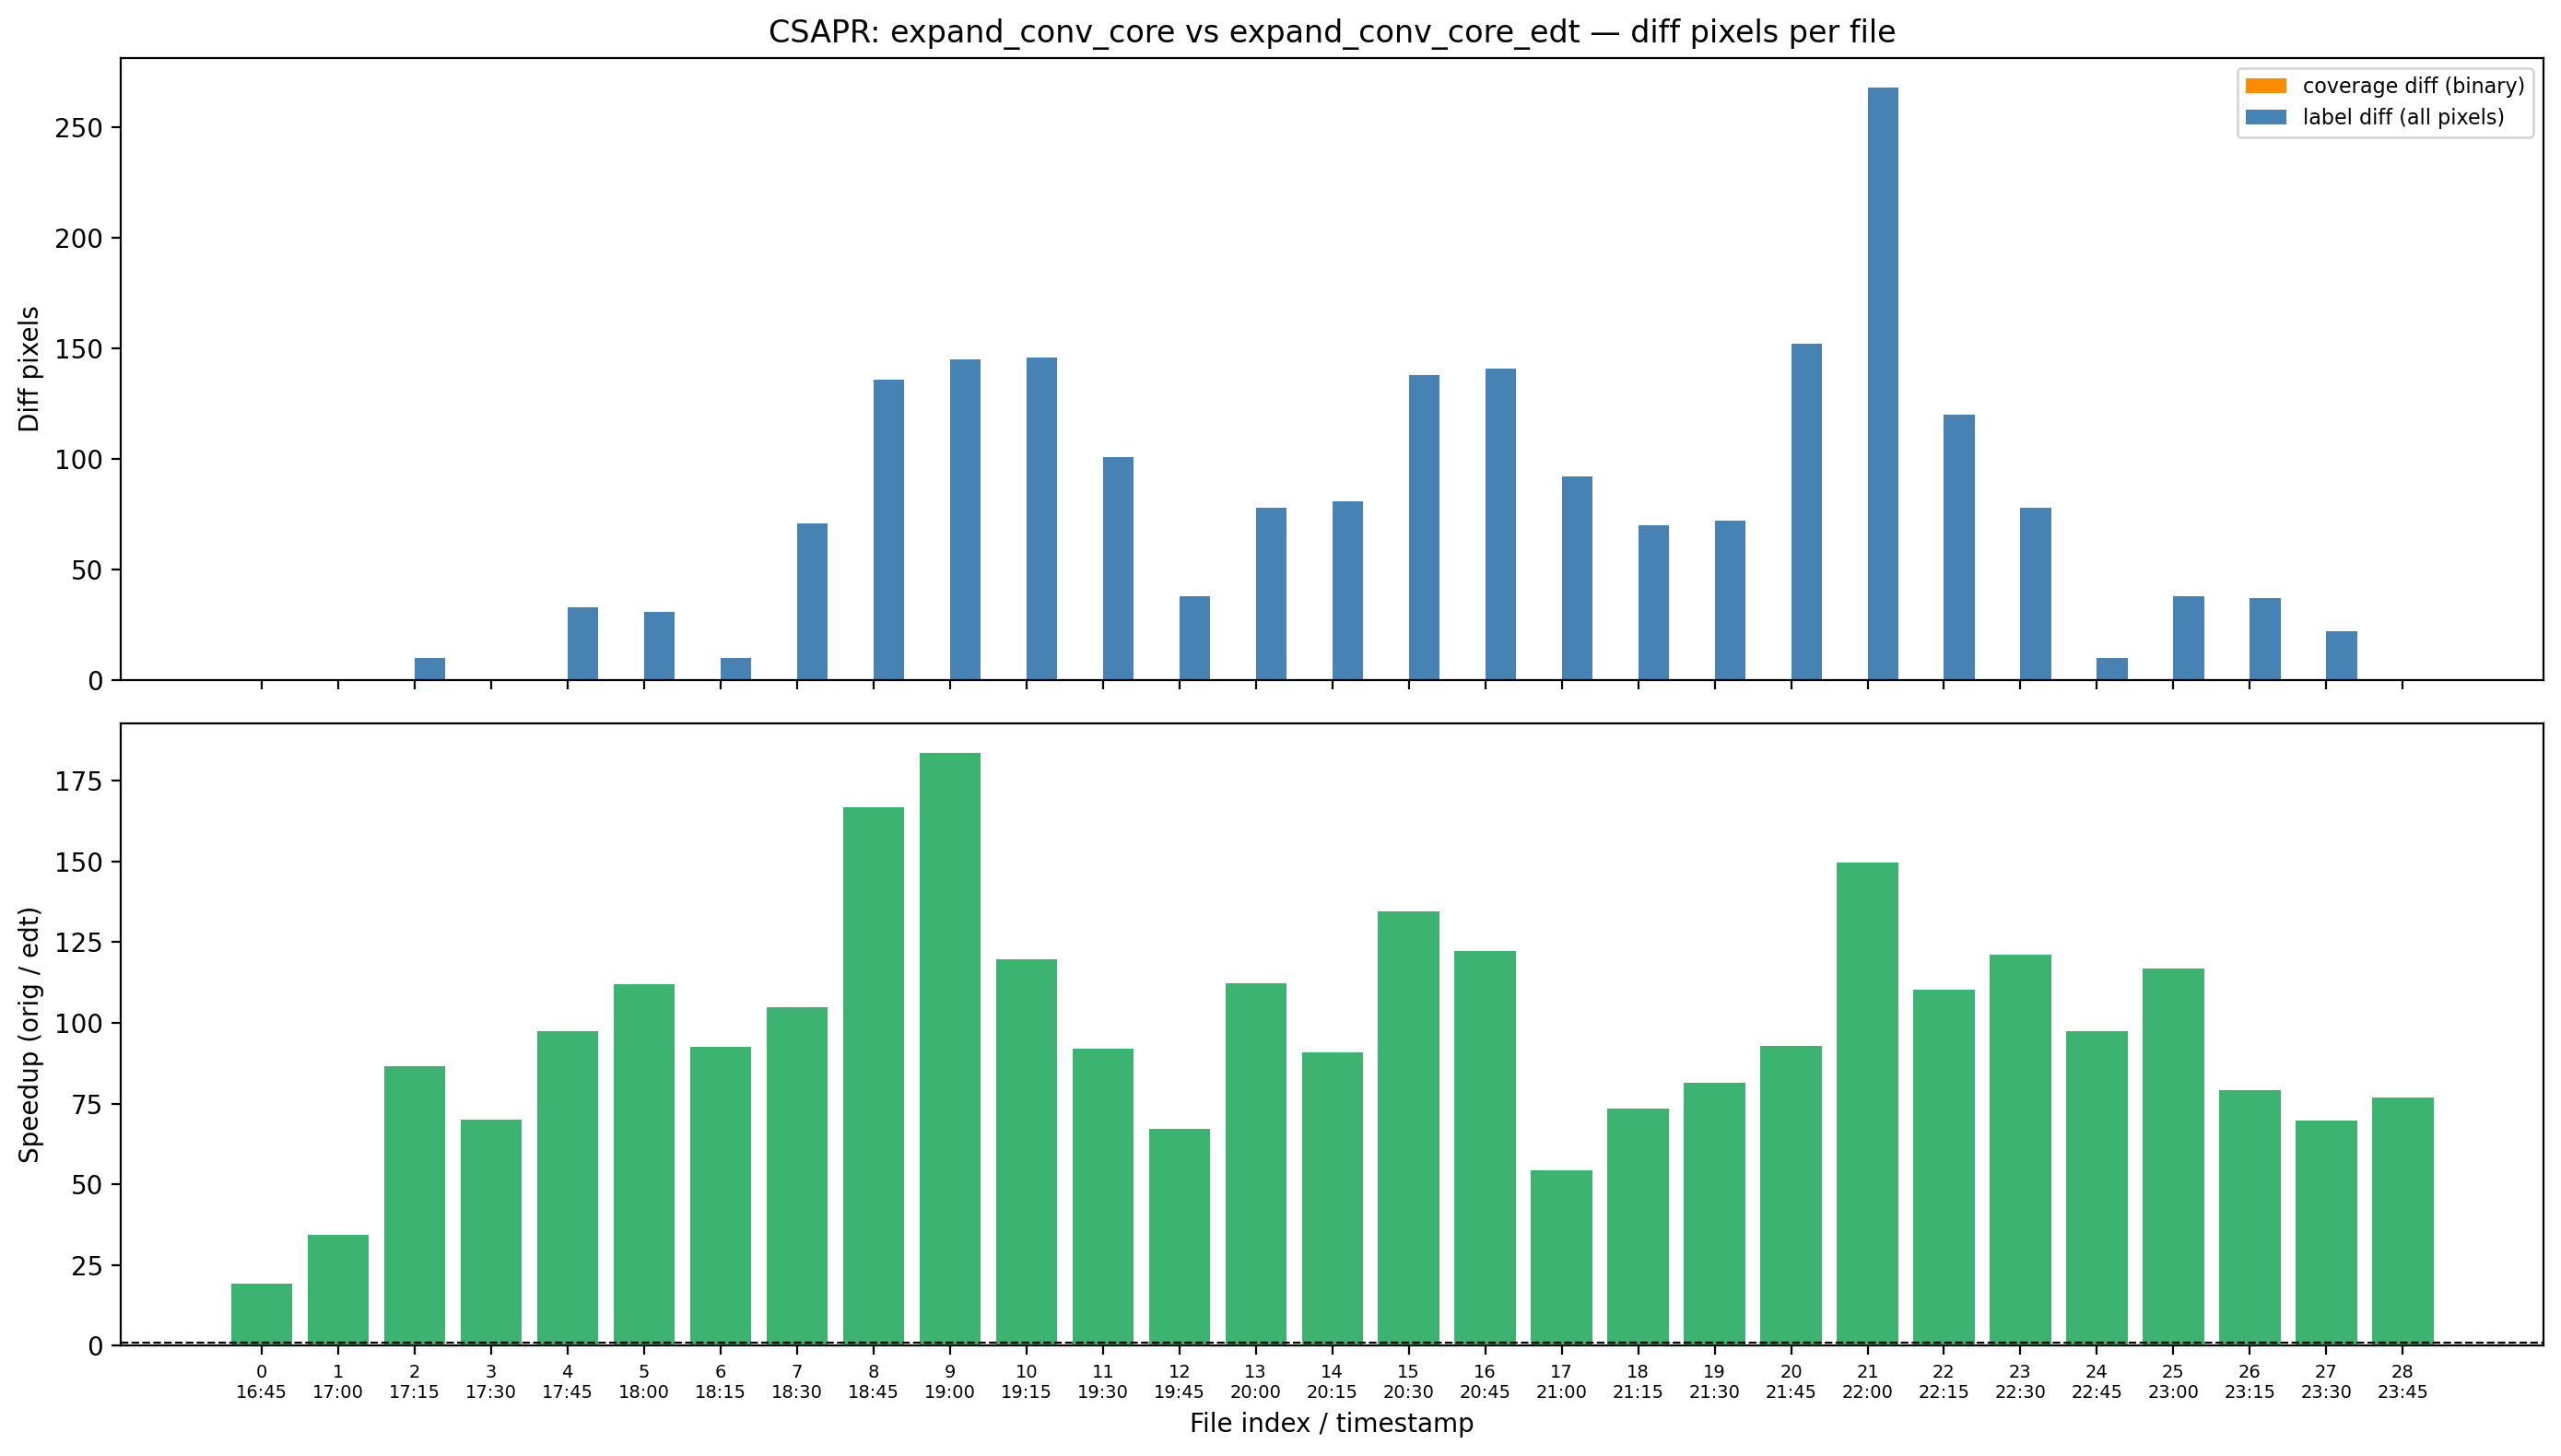

In [6]:
n_cov_diff_arr   = [r['n_cov_diff'] for r in results]
n_label_diff_arr = [r['n_label_diff'] for r in results]
speedup_arr      = [r['t_orig'] / max(r['t_edt'], 1e-9) for r in results]
xlabels          = [f"{r['fi']}\n{r['timestamp'].strftime('%H:%M')}" for r in results]
xidx             = np.arange(len(results))

fig, axes = plt.subplots(2, 1, figsize=(max(14, len(results) * 0.45), 8), dpi=200, sharex=True)

w = 0.4
axes[0].bar(xidx - w/2, n_cov_diff_arr,   width=w, color='darkorange', label='coverage diff (binary)')
axes[0].bar(xidx + w/2, n_label_diff_arr,  width=w, color='steelblue',  label='label diff (all pixels)')
axes[0].set_ylabel('Diff pixels')
axes[0].set_title(f'{DEMO.upper()}: expand_conv_core vs expand_conv_core_edt — diff pixels per file')
axes[0].legend(fontsize=8)

axes[1].bar(xidx, speedup_arr, color='mediumseagreen', align='center')
axes[1].axhline(1.0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('Speedup (orig / edt)')
axes[1].set_xlabel('File index / timestamp')
axes[1].set_xticks(xidx)
axes[1].set_xticklabels(xlabels, fontsize=7)

plt.tight_layout()
plt.show()


## 5  Helper: 3-panel orig | EDT | diff visualization

In [ ]:
def plot_3panel_expand_diff(r, lat2d, lon2d, demo_label):
    """
    3-panel map: Panel 1 = original expand_conv_core (labeled),
    Panel 2 = EDT expand_conv_core_edt (labeled),
    Panel 3 = 4-category label diff:
    -1=orig-only (blue), 0=agree (white),
    +1=EDT-only (red), +2=label-mismatch (orange).
    """
    exp_orig = r['exp_orig']
    exp_edt = r['exp_edt']
    label_diff_map = r['label_diff_map']
    n_edt_only = r['n_edt_only']
    n_orig_only = r['n_orig_only']
    n_agree_on = r['n_agree_on']
    n_cov_diff = r['n_cov_diff']
    n_label_mismatch = r['n_label_mismatch']
    n_label_diff = r['n_label_diff']
    ts = r['timestamp']
    fi = r['fi']
    fname = r['fname']
    t_orig = r['t_orig']
    t_edt = r['t_edt']
    speedup = t_orig / max(t_edt, 1e-9)

    # ── Colormap for labeled arrays (white for bg, tab20 for cells) ──────────
    n_labels = max(int(exp_orig.max()), int(exp_edt.max()), 1)
    tab20    = plt.cm.tab20(np.linspace(0, 1, 20))
    colors   = np.vstack([[1, 1, 1, 1],
                        np.tile(tab20, (n_labels // 20 + 1, 1))[:n_labels]])
    cmap_labeled = mcolors.ListedColormap(colors)
    bounds_lab   = np.arange(-0.5, n_labels + 1.5)
    norm_lab     = mcolors.BoundaryNorm(bounds_lab, cmap_labeled.N)

    # ── 4-category colormap for diff panel ───────────────────────────────────
    # -1=orig-only (blue), 0=agree (white), 1=EDT-only (red), 2=label-mismatch (orange)
    cmap_diff = mcolors.ListedColormap(['#2166ac', 'white', '#d6604d', '#ff8c00'])
    norm_diff = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap_diff.N)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=200)
    ts_str = ts.strftime('%Y-%m-%d %H:%M UTC')

    # Panel 1: original
    axes[0].pcolormesh(lon2d, lat2d, exp_orig, cmap=cmap_labeled, norm=norm_lab, shading='auto')
    axes[0].set_title(f'Original (expand_conv_core)\n{ts_str}')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    # Panel 2: EDT
    axes[1].pcolormesh(lon2d, lat2d, exp_edt, cmap=cmap_labeled, norm=norm_lab, shading='auto')
    axes[1].set_title(f'EDT (expand_conv_core_edt)\n{ts_str}')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

    # Panel 3: 4-category label diff
    im2 = axes[2].pcolormesh(lon2d, lat2d, label_diff_map,
                            cmap=cmap_diff, norm=norm_diff, shading='auto')
    cb2 = plt.colorbar(im2, ax=axes[2], ticks=[-1, 0, 1, 2])
    cb2.set_ticklabels(['Orig only', 'Agree', 'EDT only', 'Label mismatch'])
    axes[2].set_title(f'Label diff (EDT vs Orig)\n{ts_str}')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    axes[2].text(
        0.01, 0.99,
        f'Orig-only      : {n_orig_only}\n'
        f'EDT-only       : {n_edt_only}\n'
        f'Label-mismatch : {n_label_mismatch}\n'
        f'Both agree     : {n_agree_on}',
        transform=axes[2].transAxes, va='top', ha='left', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85),
    )

    fig.suptitle(
        f'{demo_label.upper()} | file={fi} | {fname}\n'
        f'Label-diff={n_label_diff} px  (cov-diff={n_cov_diff}, label-mismatch={n_label_mismatch}) | '
        f'Speedup={speedup:.1f}x (orig={t_orig:.3f}s, edt={t_edt:.4f}s)',
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


## 6  Top-N files with largest coverage differences

Top 10 files with largest coverage difference (out of 29):
  #1  fi=21  ts=2019-01-25 22:00  cov_diff=   0  label_diff= 268  speedup=149.6x
  #2  fi=20  ts=2019-01-25 21:45  cov_diff=   0  label_diff= 152  speedup=92.9x
  #3  fi=10  ts=2019-01-25 19:15  cov_diff=   0  label_diff= 146  speedup=119.6x
  #4  fi= 9  ts=2019-01-25 19:00  cov_diff=   0  label_diff= 145  speedup=183.5x
  #5  fi=16  ts=2019-01-25 20:45  cov_diff=   0  label_diff= 141  speedup=122.3x
  #6  fi=15  ts=2019-01-25 20:30  cov_diff=   0  label_diff= 138  speedup=134.6x
  #7  fi= 8  ts=2019-01-25 18:45  cov_diff=   0  label_diff= 136  speedup=166.9x
  #8  fi=22  ts=2019-01-25 22:15  cov_diff=   0  label_diff= 120  speedup=110.4x
  #9  fi=11  ts=2019-01-25 19:30  cov_diff=   0  label_diff= 101  speedup=91.9x
  #10  fi=17  ts=2019-01-25 21:00  cov_diff=   0  label_diff=  92  speedup=54.4x



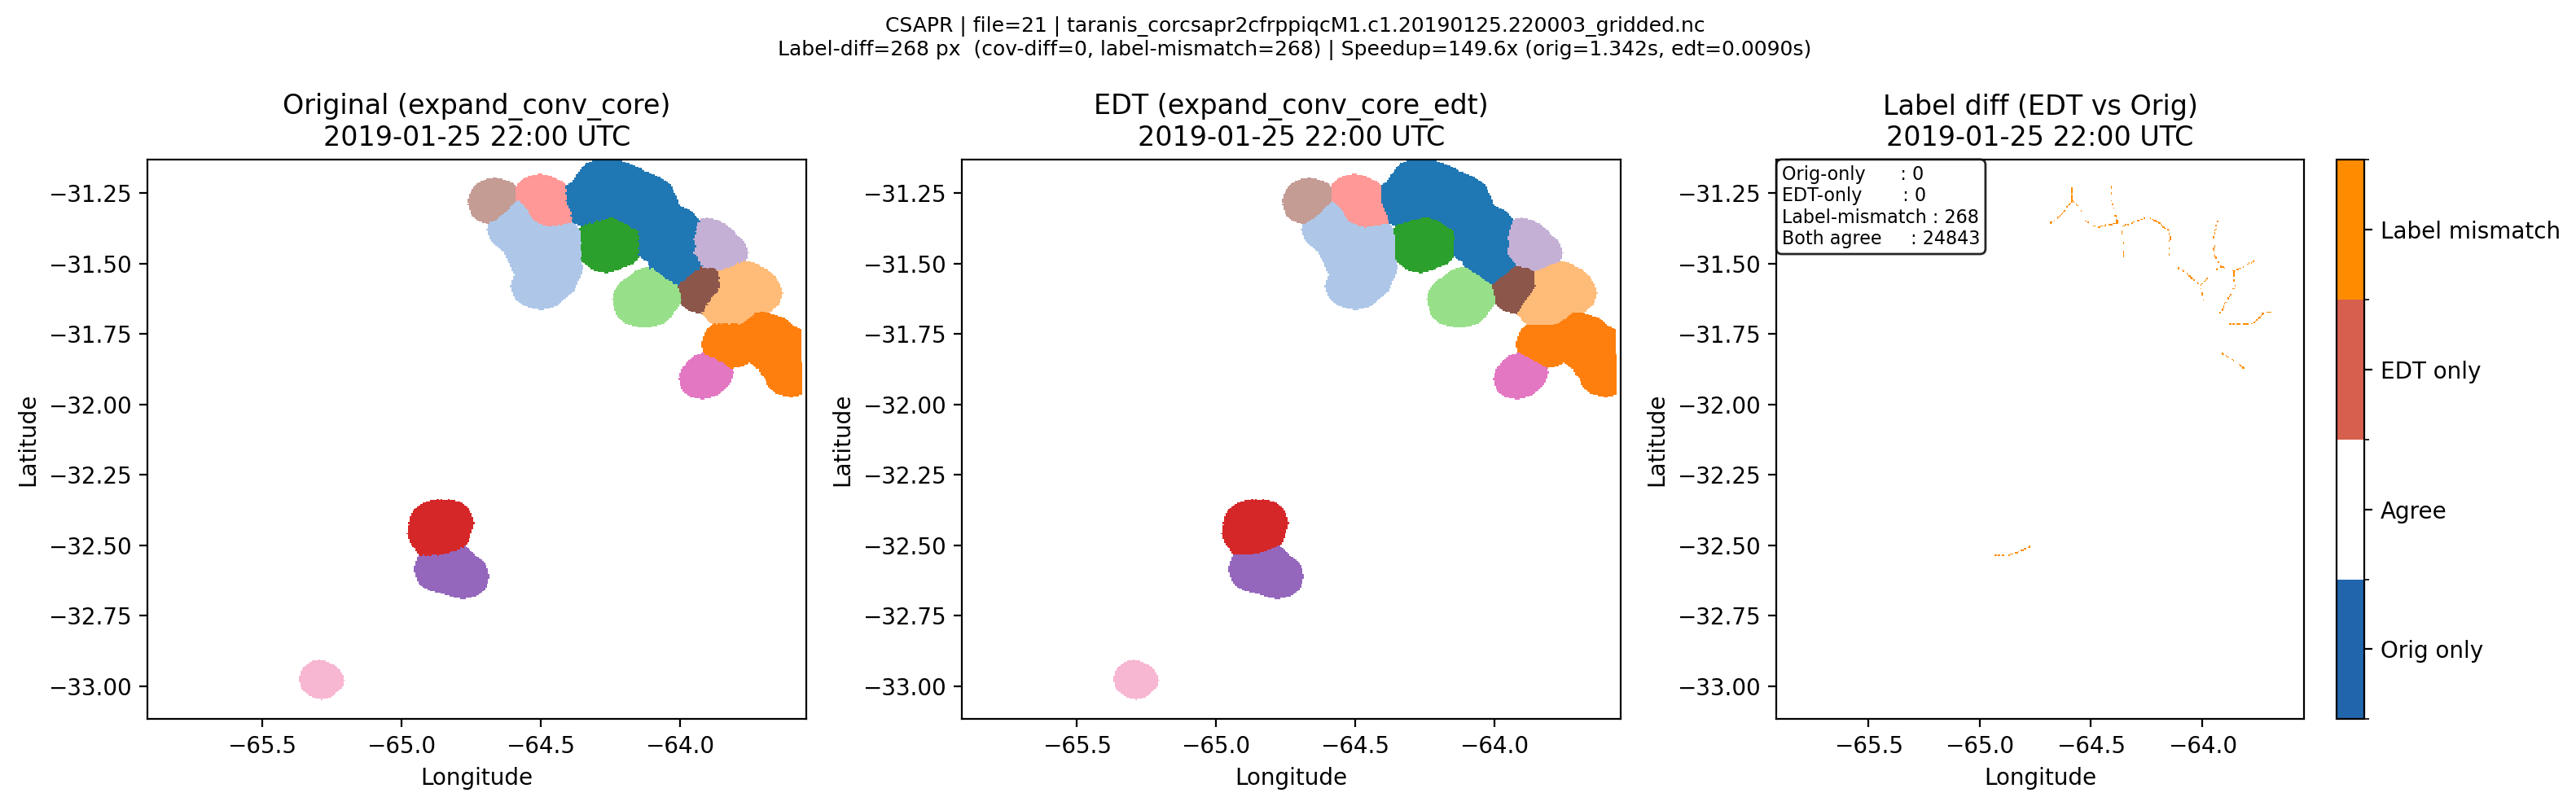

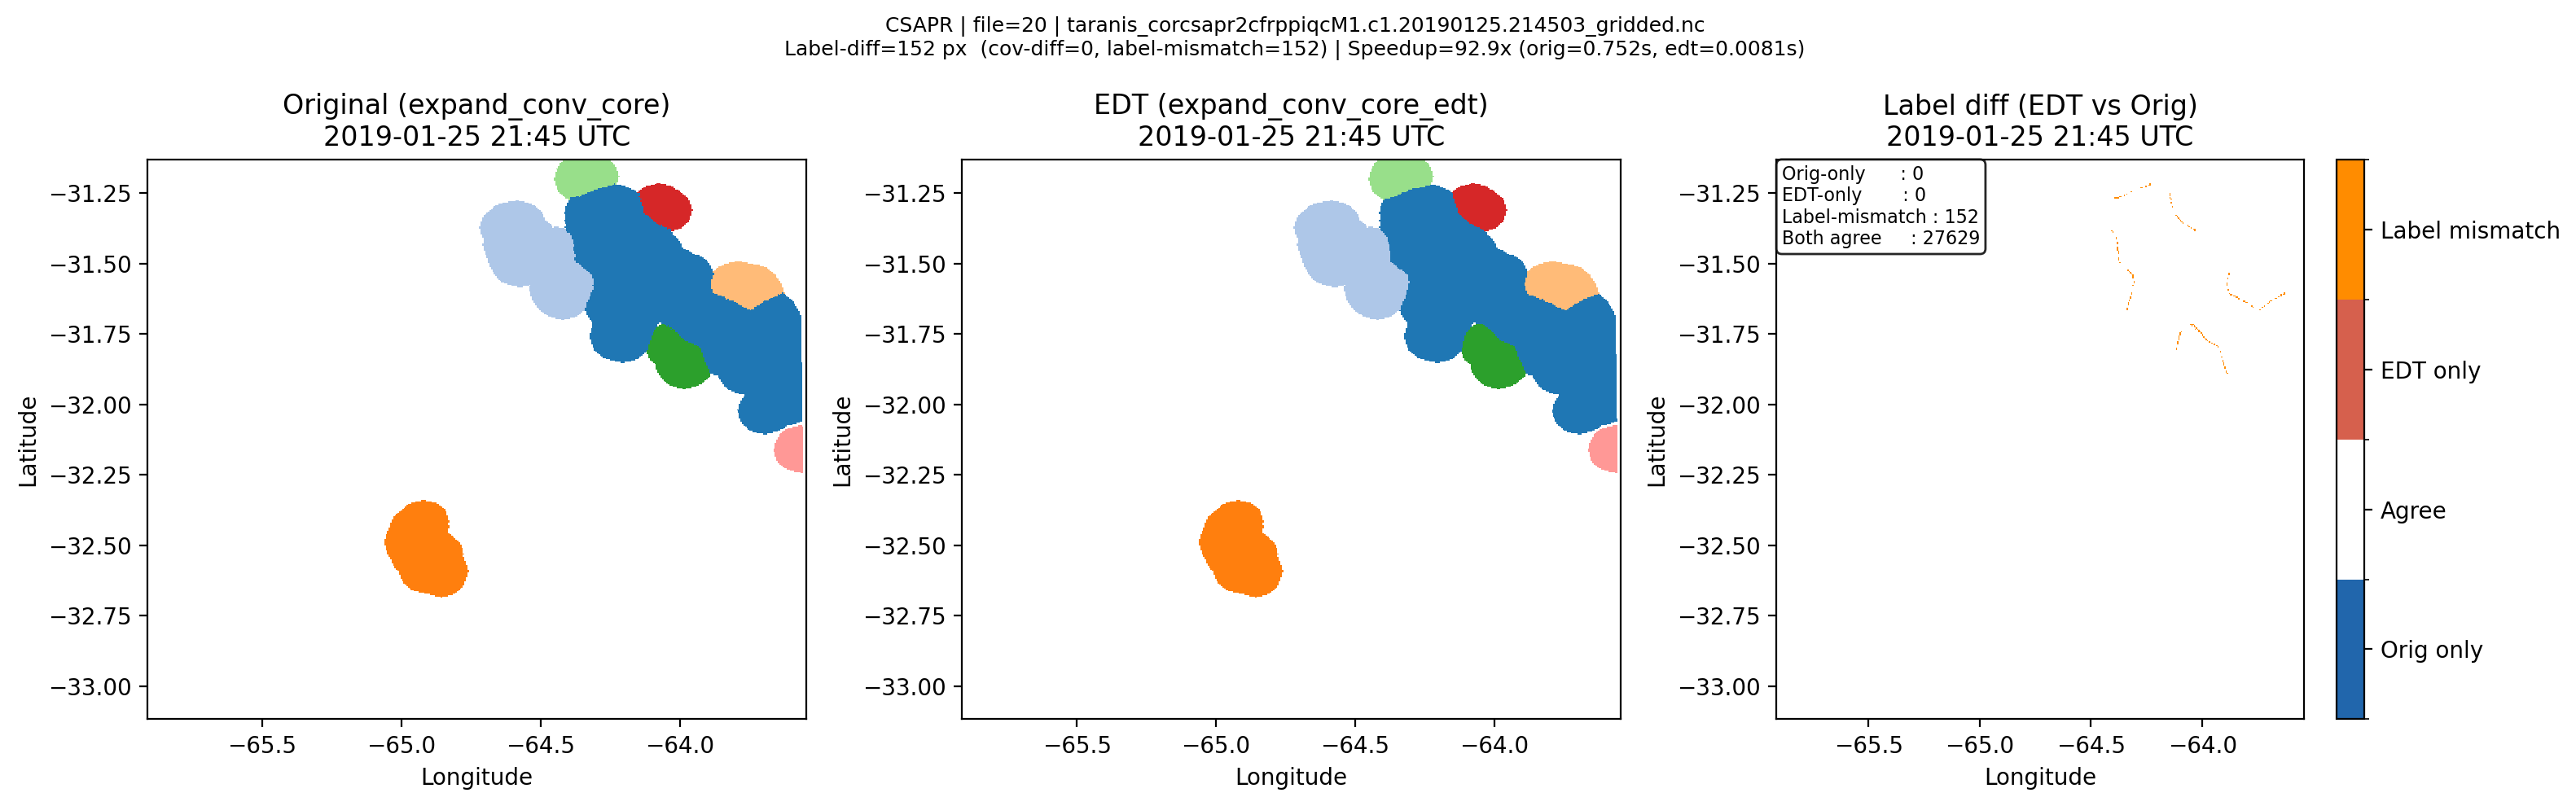

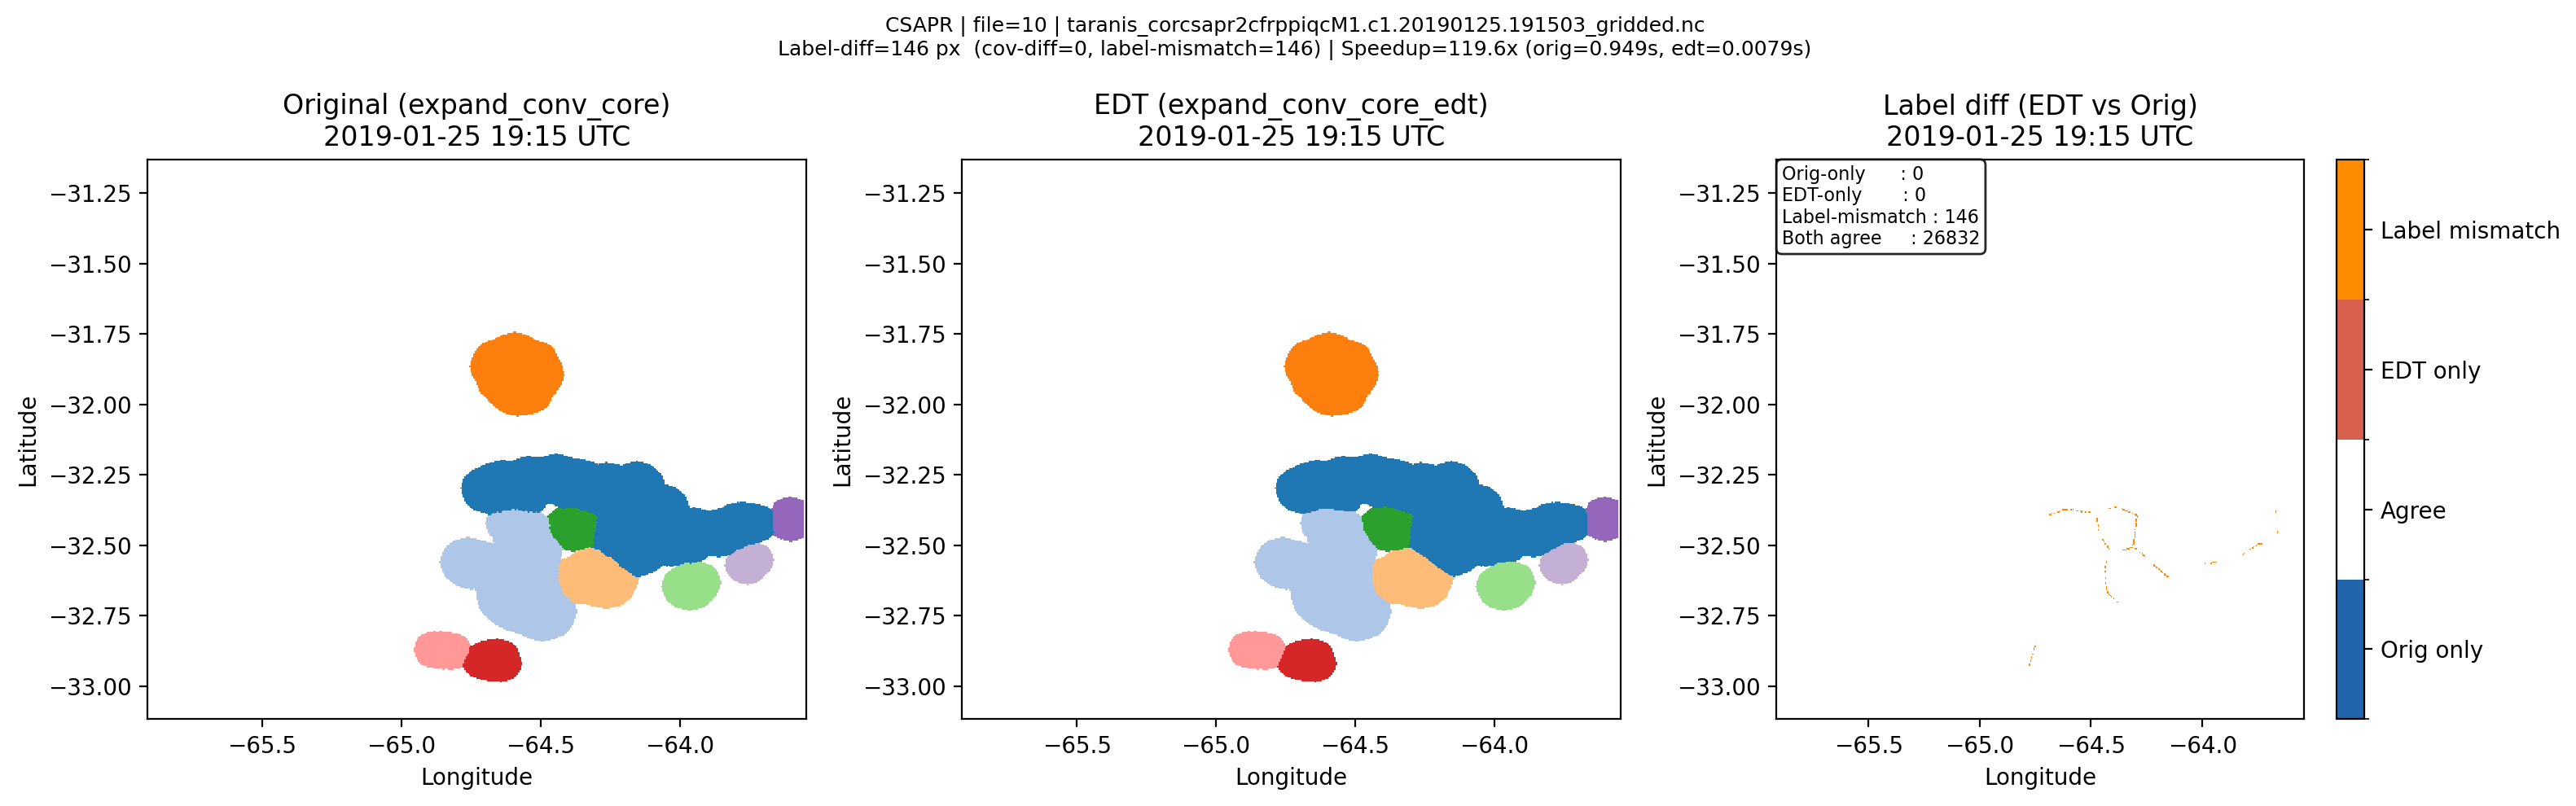

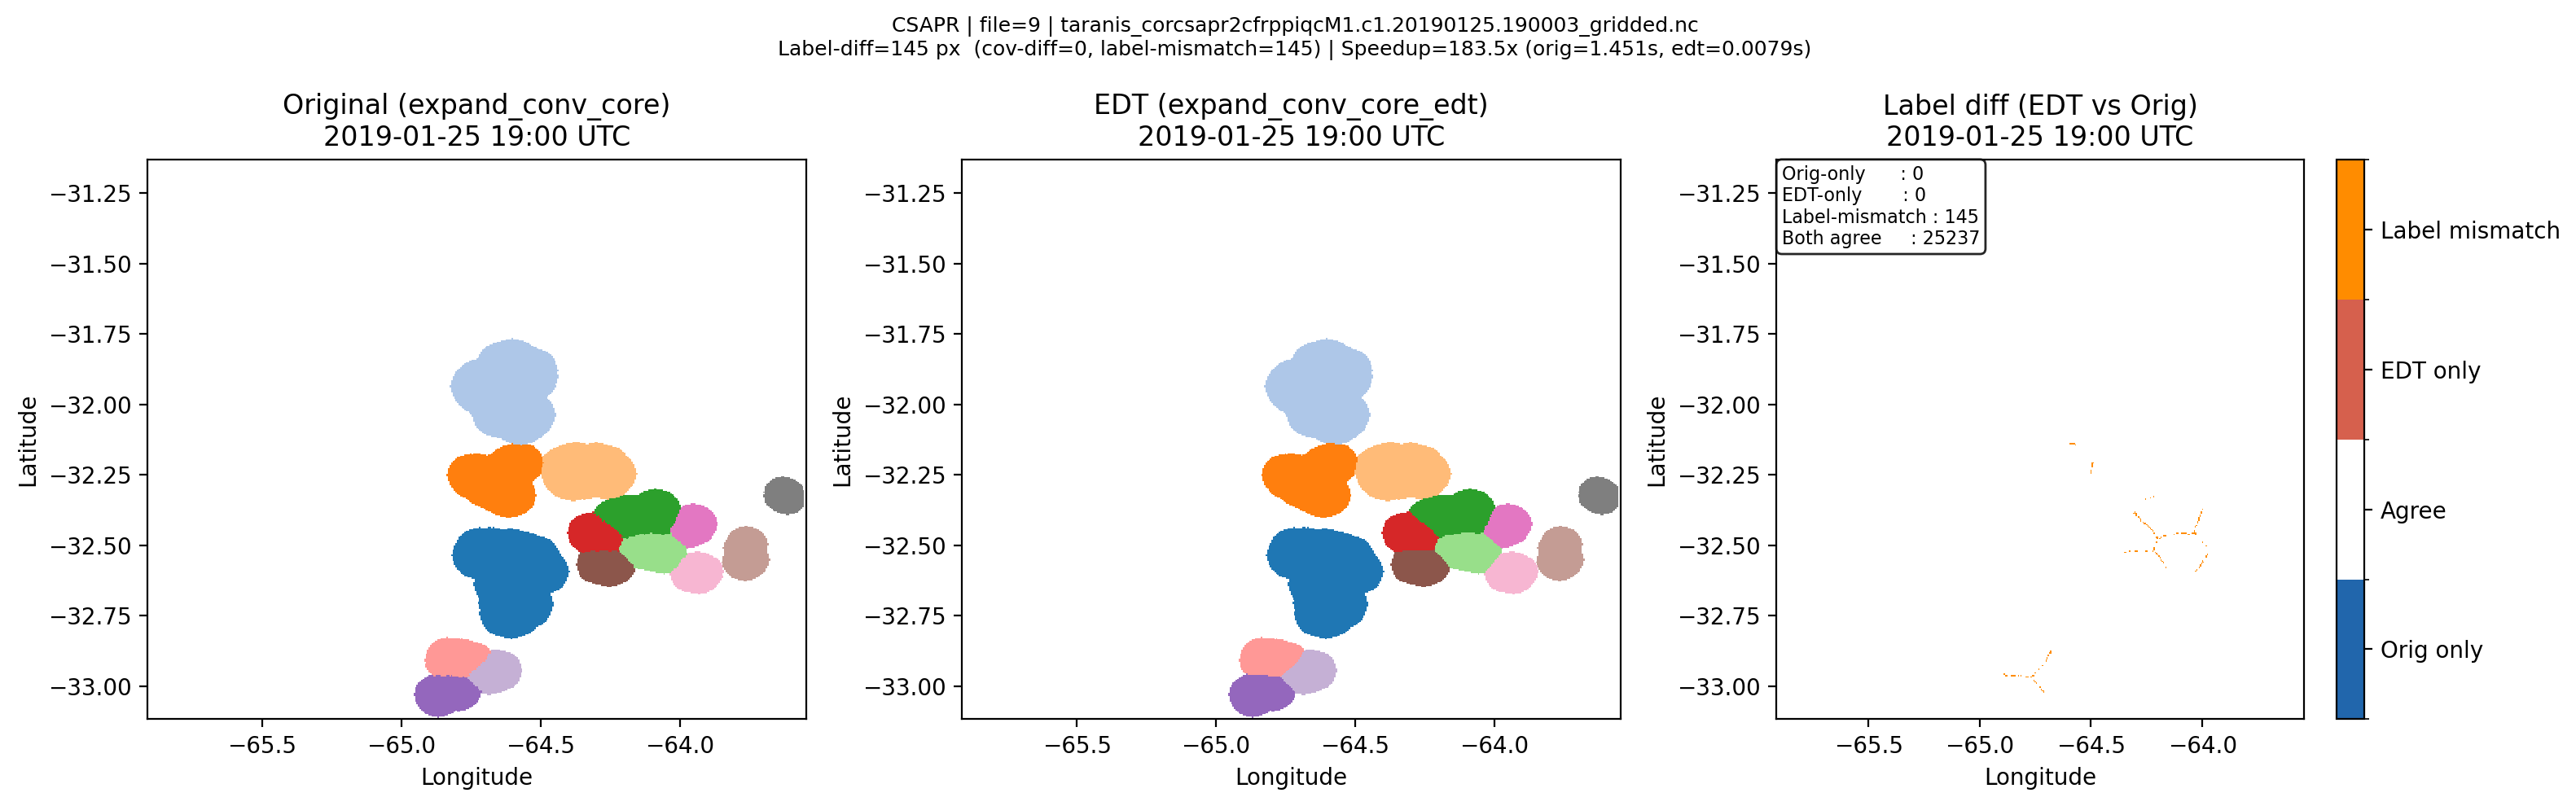

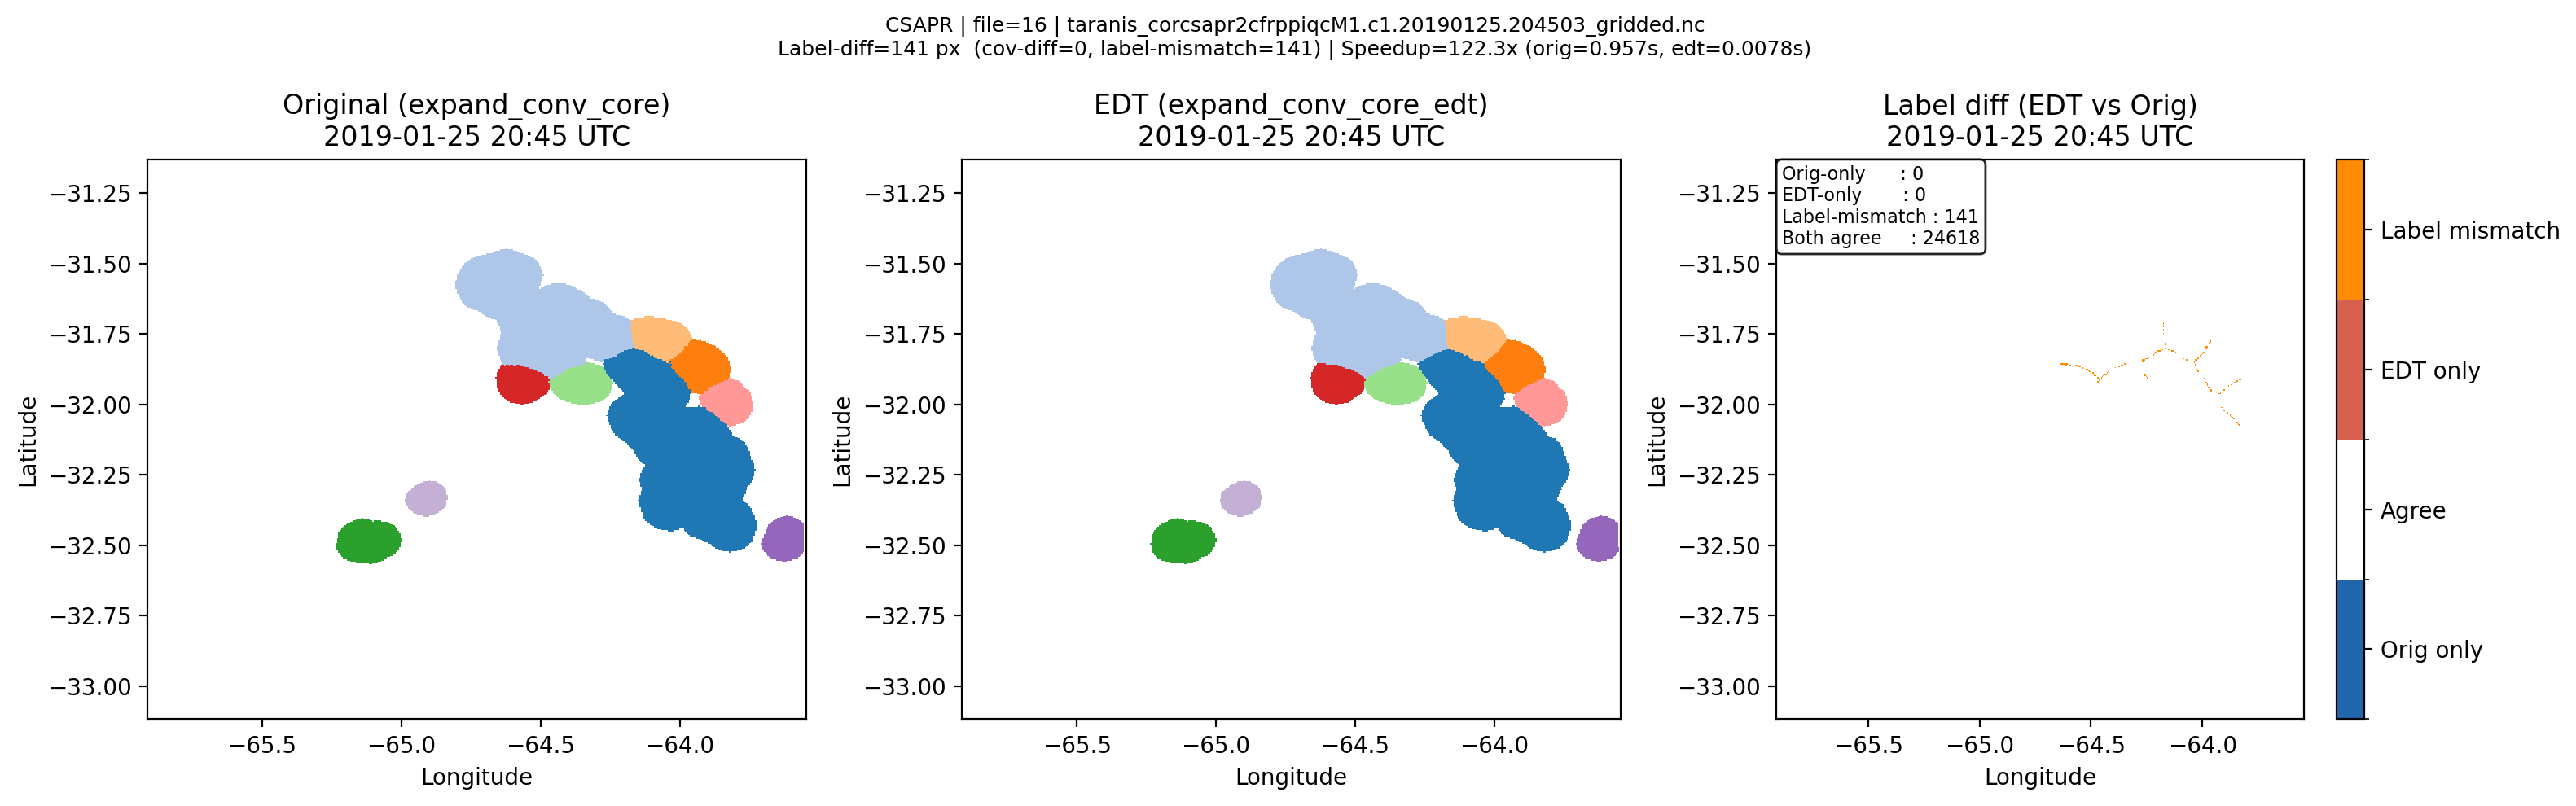

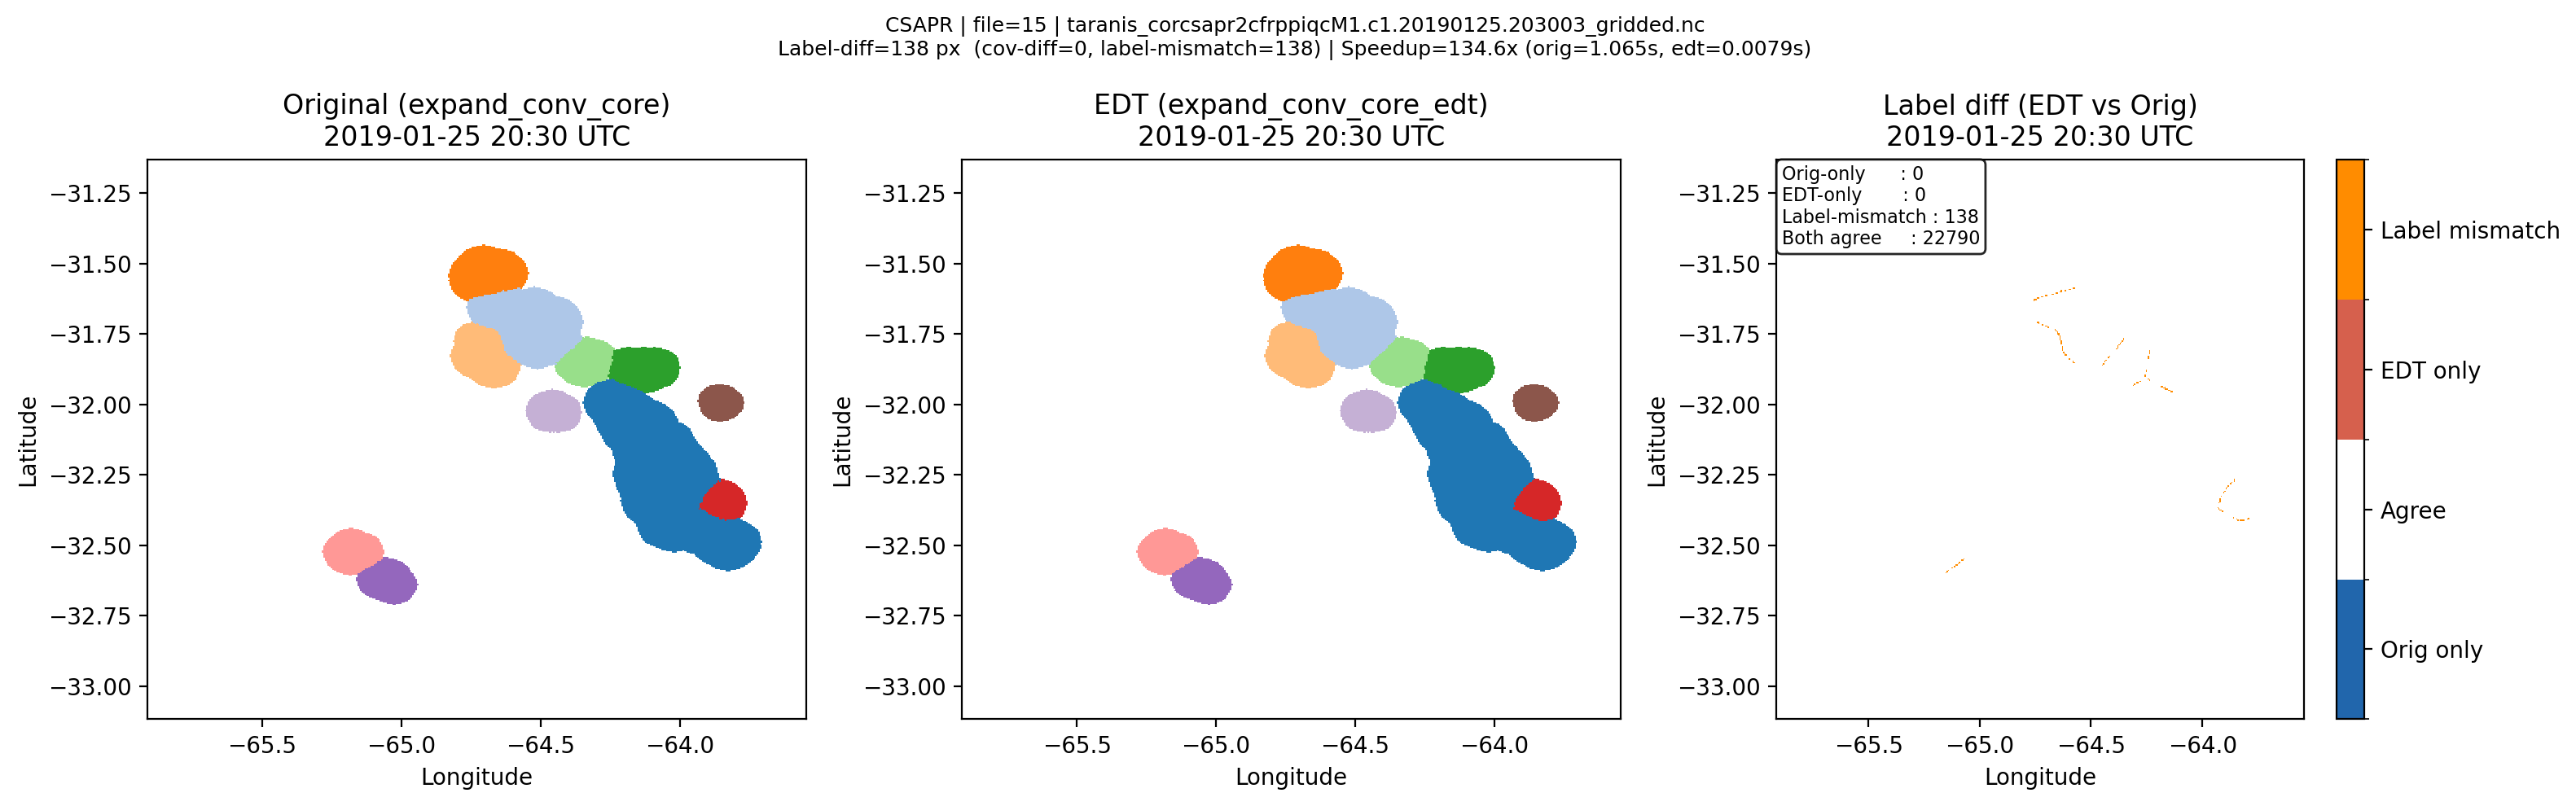

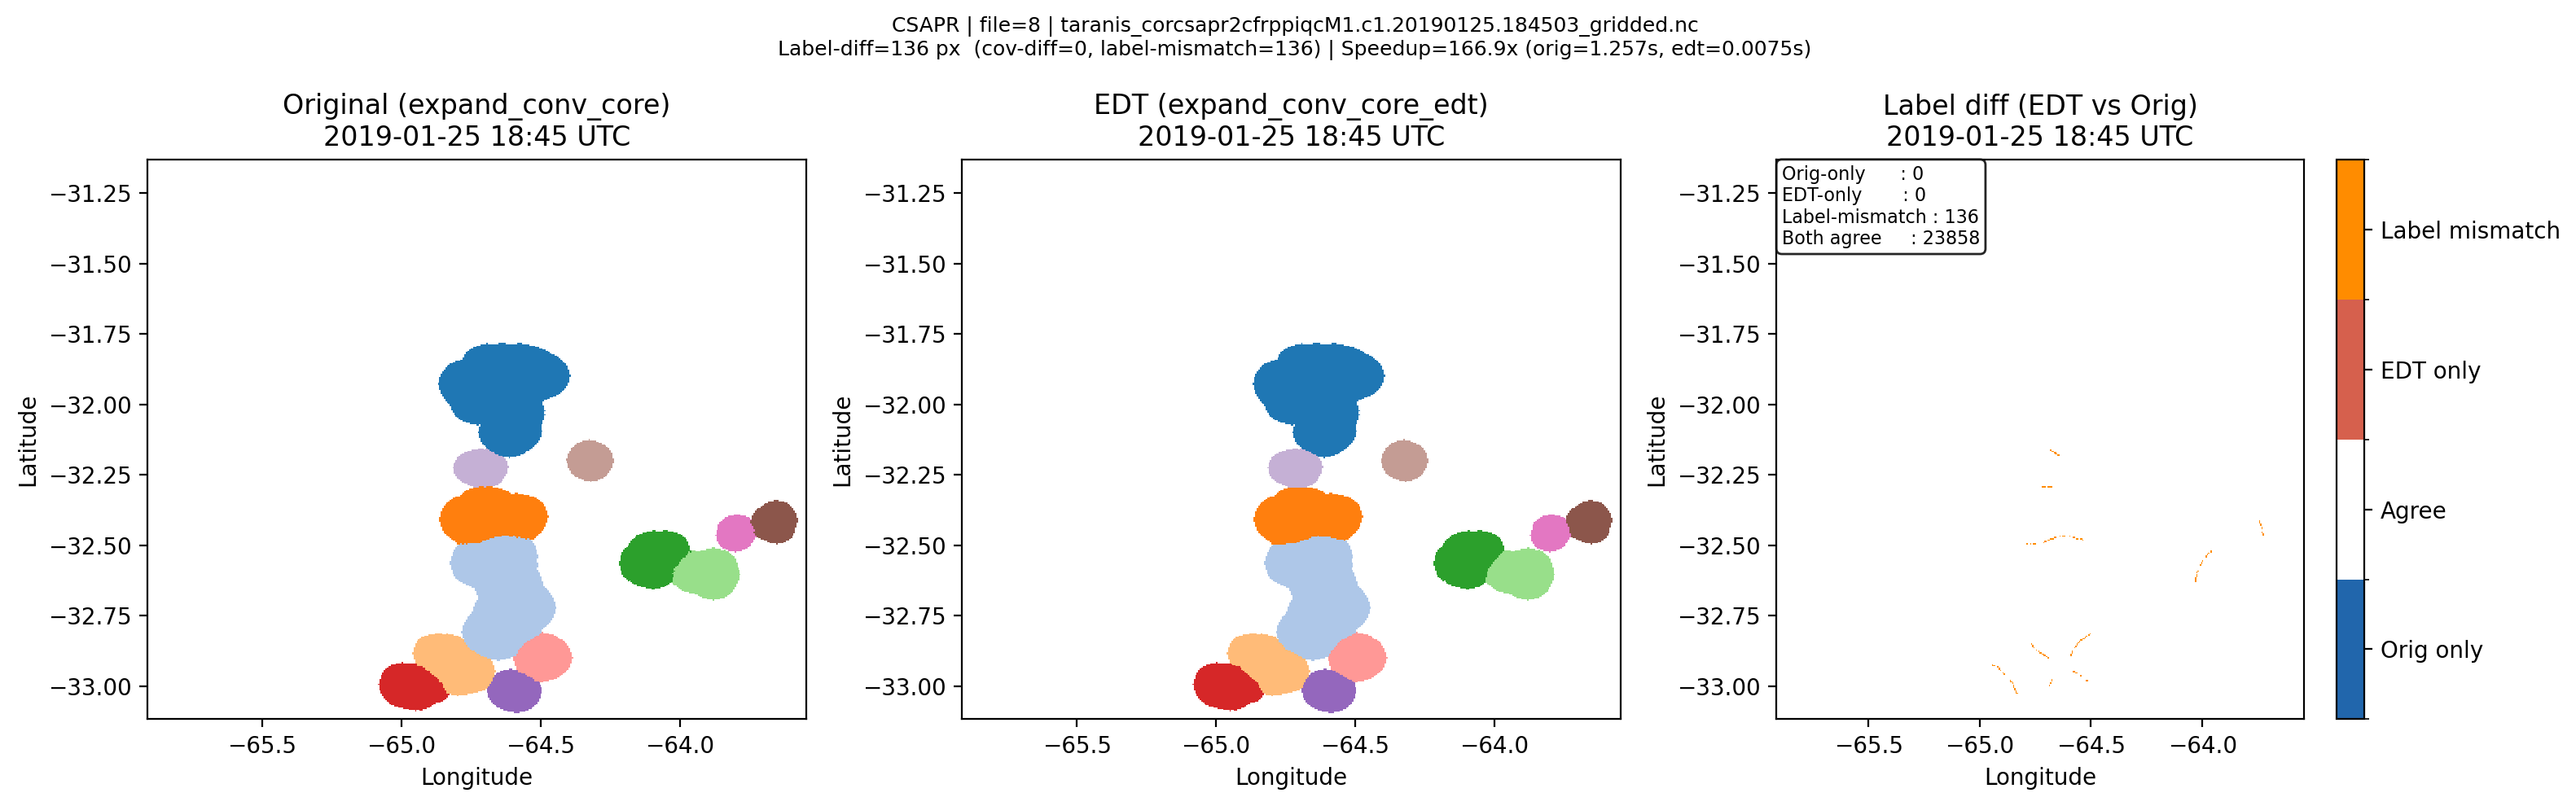

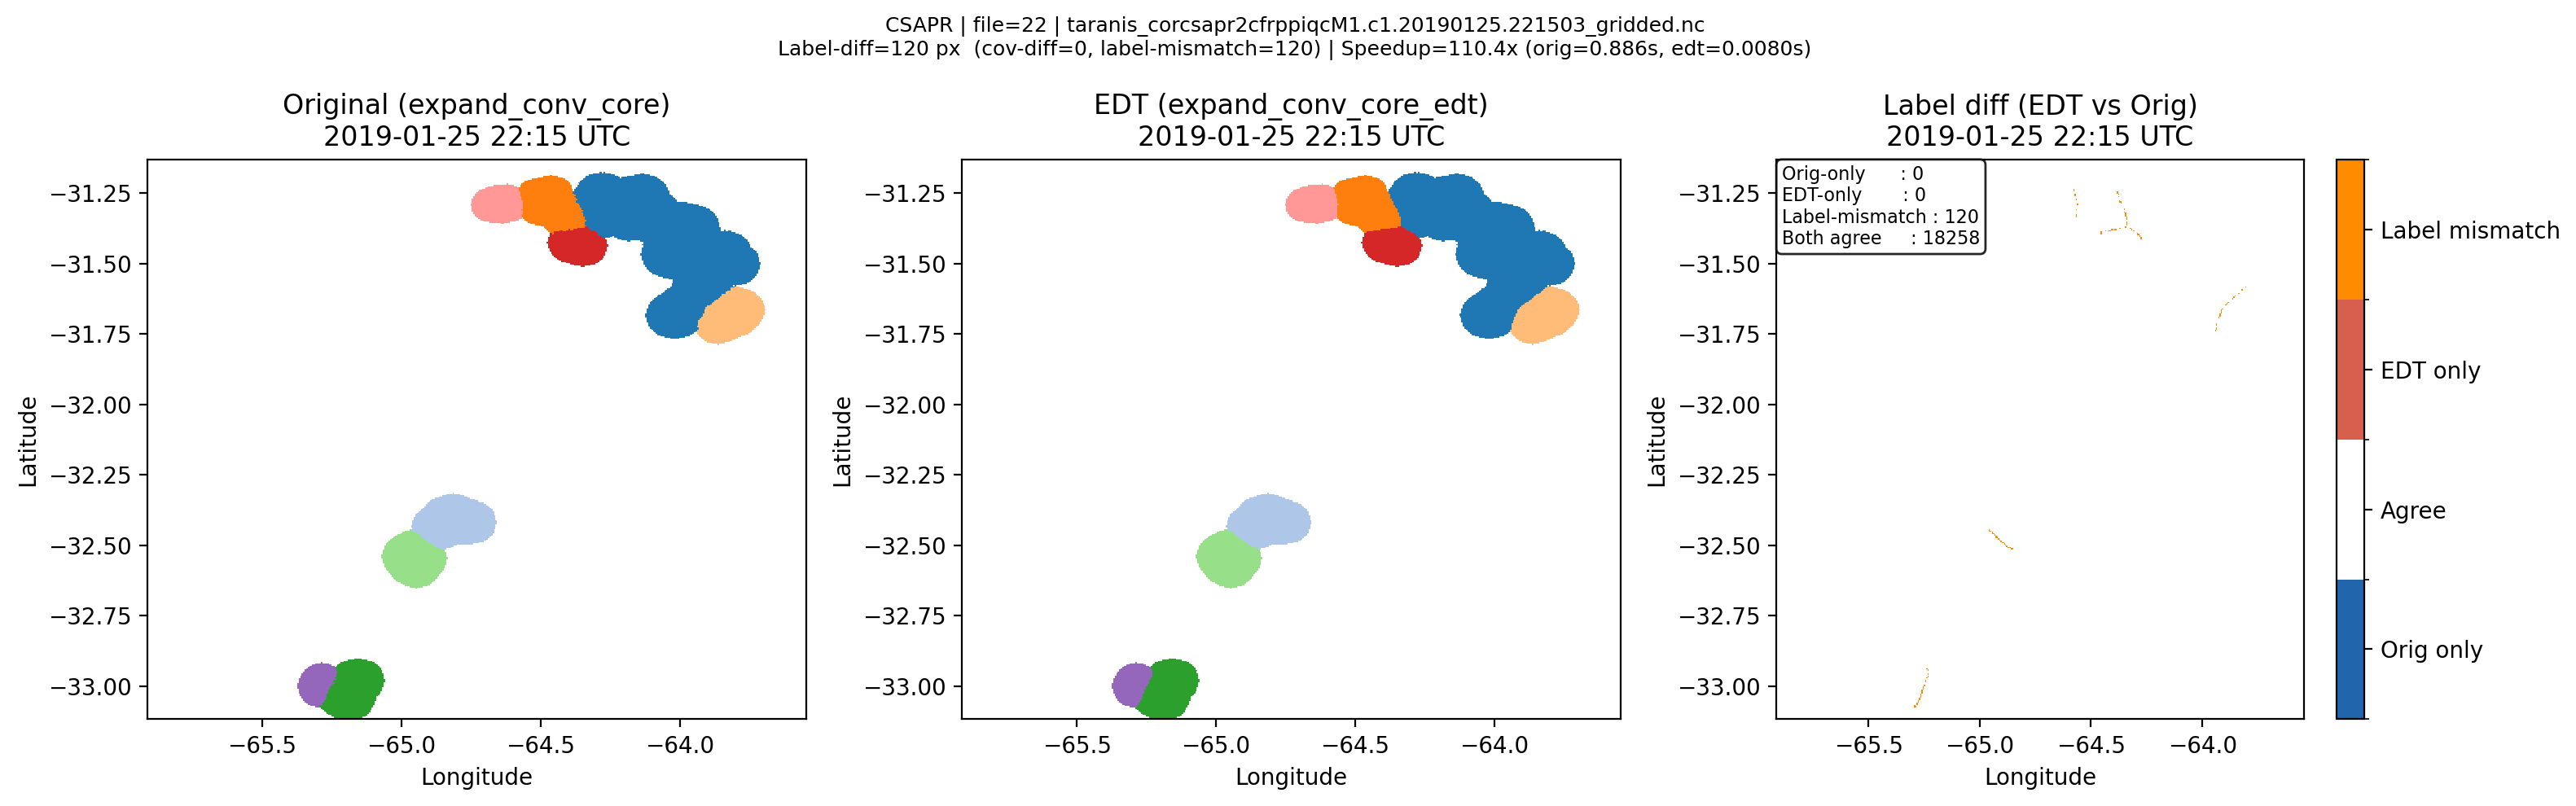

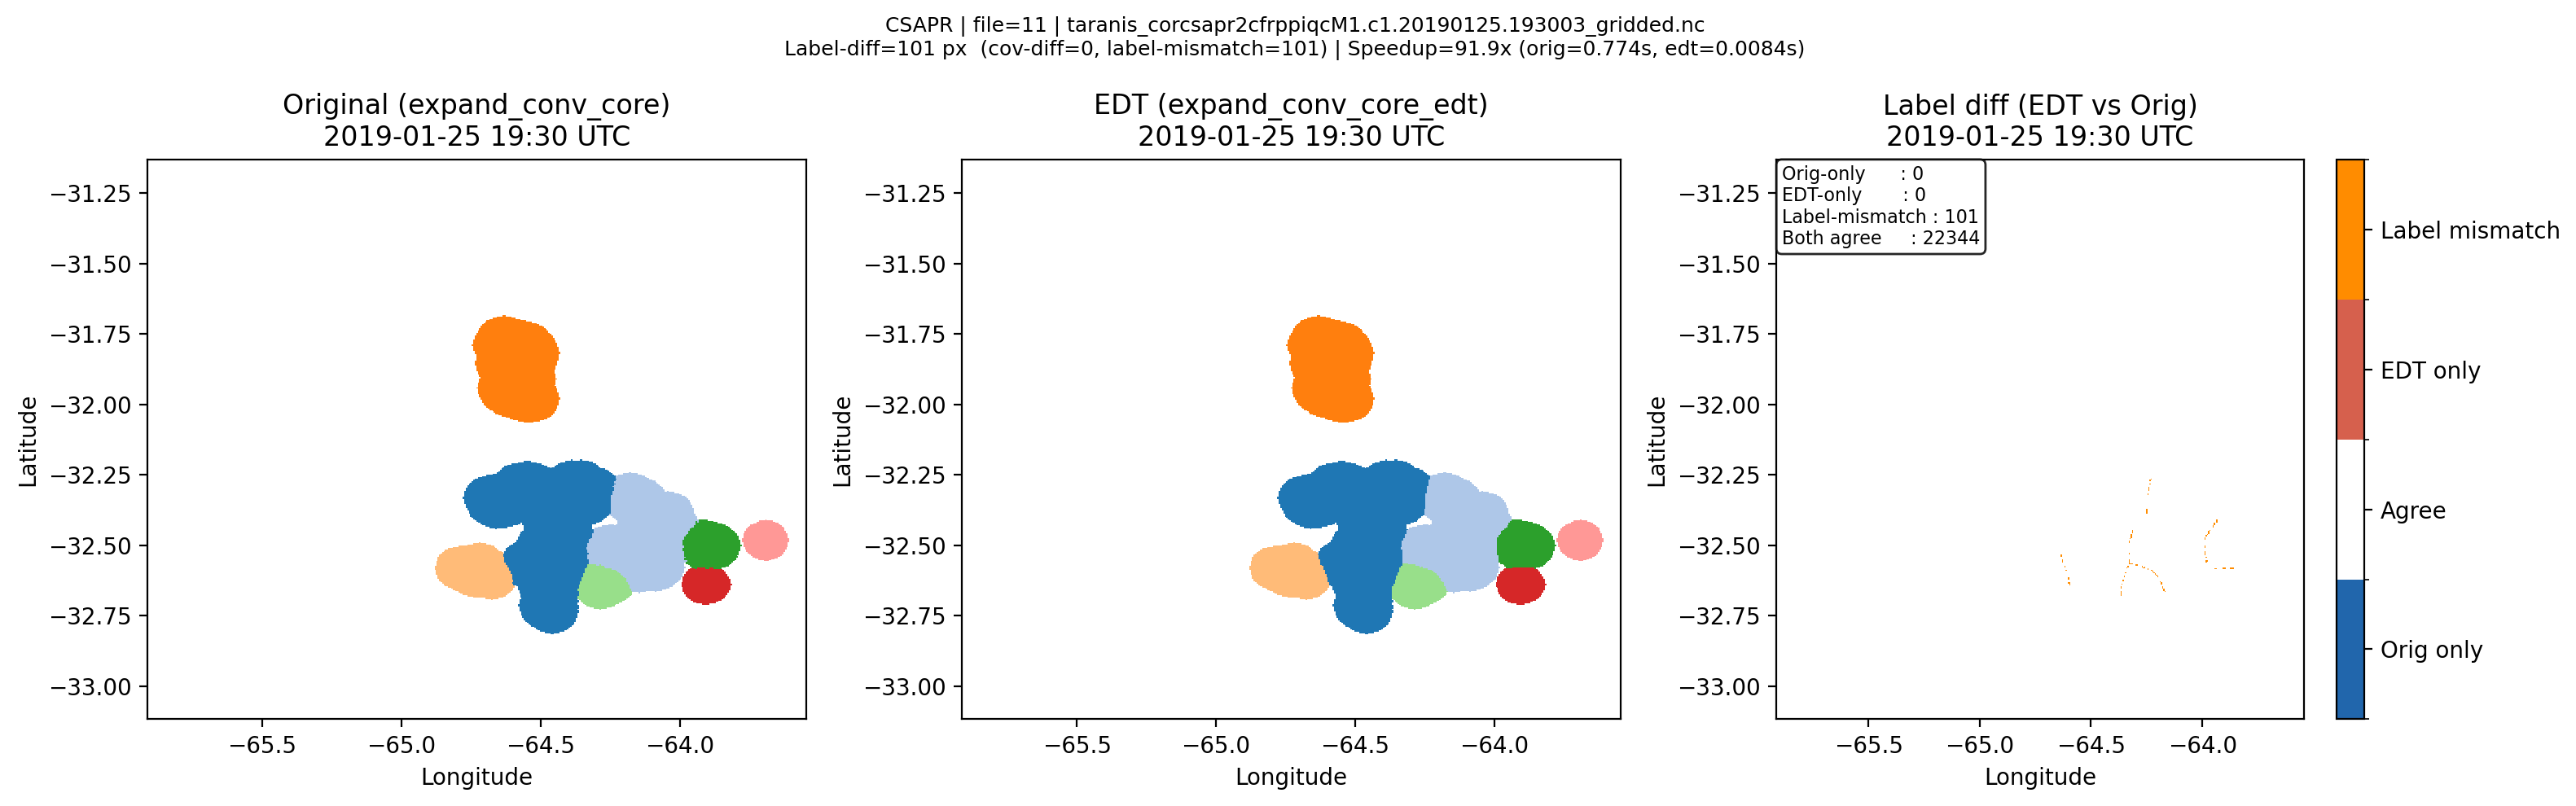

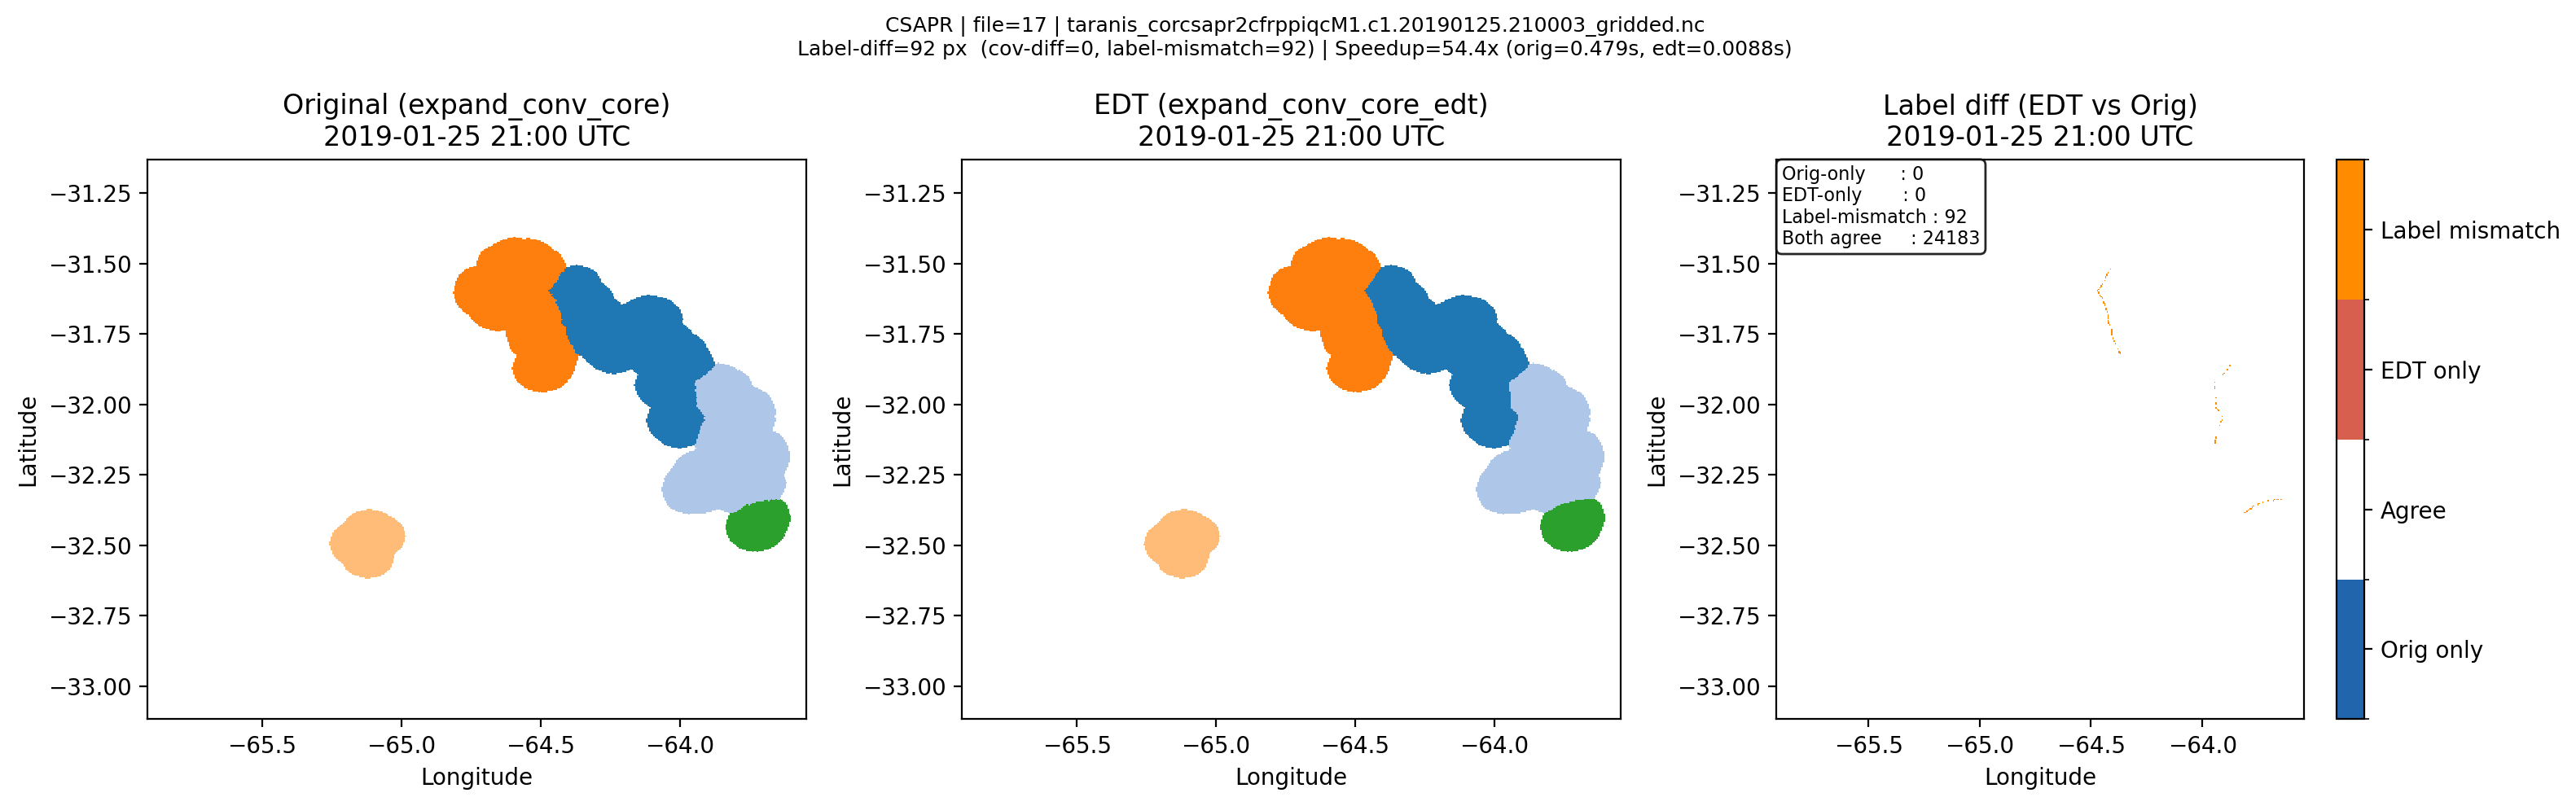

In [13]:
# Sort by n_cov_diff descending; select top N_TOP_PLOTS
# results_sorted = sorted(results, key=lambda r: r['n_cov_diff'], reverse=True)
results_sorted = sorted(results, key=lambda r: r['n_label_diff'], reverse=True)
top_results    = results_sorted[:N_TOP_PLOTS]

print(f'Top {N_TOP_PLOTS} files with largest coverage difference (out of {len(results)}):')
for i, r in enumerate(top_results):
    speedup = r['t_orig'] / max(r['t_edt'], 1e-9)
    print(f'  #{i+1}  fi={r["fi"]:2d}  ts={r["timestamp"].strftime("%Y-%m-%d %H:%M")}  '
          f'cov_diff={r["n_cov_diff"]:4d}  label_diff={r["n_label_diff"]:4d}  '
          f'speedup={speedup:.1f}x')

print()
for r in top_results:
    plot_3panel_expand_diff(r, lat2d, lon2d, DEMO)
